# A visual tour of the cleaned panel

Orientation only — no modelling, no decisions. This notebook answers *"what does
the data actually look like?"* before notebooks 03+ build on it: how much data
there is and where the gaps are, the series themselves, the inflation
environment, seasonality, and how the hotel categories compare.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SRC = Path.cwd() / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog

LOG = AuditLog("02_data_overview")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "axes.axisbelow": True})

df = pd.read_parquet(C.P_ANALYSIS)
panel_long = pd.read_parquet(C.P_PANEL_LONG)
cpi = pd.read_parquet(C.P_CPI_MONTHLY)
capq = pd.read_parquet(C.P_CAPACITY_Q)

LAB = C.CATEGORY_LABELS
COV = (pd.Timestamp(C.COVID_START), pd.Timestamp(C.COVID_END))
# category display order: hotel tiers first, then the composites / para-hotels
CAT_ORDER = [c for c in LAB if c in set(df.hotel_category.unique())]
# one row per date (calendar + CPI columns are identical across categories)
by_date = (df.groupby("date")
             .agg(cpi_gba=("cpi_gba", "first"),
                  infl_mom_gba=("infl_mom_gba", "first"),
                  infl_yoy_gba=("infl_yoy_gba", "first"))
             .reset_index())


def covid_band(ax):
    ax.axvspan(*COV, color="0.6", alpha=.22, lw=0, zorder=0)


def save(fig, name):
    fig.tight_layout()
    fig.savefig(C.OUT_FIG / name)
    LOG.log("figure", name)
    plt.show()


print(f"panel        : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"date range   : {df.date.min():%Y-%m} .. {df.date.max():%Y-%m}  "
      f"({df.date.nunique()} months)")
print(f"categories   : {df.hotel_category.nunique()}")
for c in CAT_ORDER:
    print(f"   {c:<22} {LAB[c]}")

panel        : 2,407 rows x 68 columns
date range   : 2008-01 .. 2026-05  (221 months)
categories   : 11
   total_hoteleros        Total hotels
   total_parahoteleros    Total para-hotels
   stars_1_2              1-2 star
   stars_3                3 star
   stars_4                4 star
   stars_5                5 star
   apart                  Apart-hotel
   boutique               Boutique
   hostel                 Hostel
   otros_resto            Other / rest
   total_composite        Total (composite)


## 1 · What is in the table

The column dictionary (from `01_build_dataset`), then a fill-rate inventory of
every column so it is obvious which fields are dense and which are sparse.

In [2]:
dd = pd.read_csv(C.P_DATA_DICT)
dd

,variable,definition,frequency,unit
0,date,month (period start),monthly,date
1,hotel_category,"canonical key: stars_1_2/3/4/5, apart, boutiqu...",—,str
2,average_rate,"avg monthly room rate, nominal pesos (Ehoba_03...",monthly,ARS
3,room_occupancy / bed_occupancy,rooms / beds occupied ÷ available (Ehoba_02a /...,monthly,% 0-100
4,travelers,"travellers hosted, hotel sector only (Ehoba_VA)",monthly,persons
5,cpi_gba / cpi_nac,"IPC Región GBA / Total nacional, Nivel general...",monthly,index
6,cpi_resthot_gba/_nac,IPC 'Restaurantes y hoteles' division (context...,monthly,index
7,infl_mom_gba / _nac,100·(CPI_t/CPI_{t-1}-1),monthly,%
8,infl_mom_gba_frac / _nac_frac,"same, FRACTION units (used by src/policies.py)",monthly,frac
9,infl_yoy_gba / _nac,100·(CPI_t/CPI_{t-12}-1),monthly,%


In [3]:
inv = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "pct_filled": (df.notna().mean() * 100).round(1),
    "n_unique": df.nunique(),
    "example": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})
inv.sort_values("pct_filled")

,dtype,non_null,pct_filled,n_unique,example
real_revenue_proxy_gba,float64,654,27.2,654,49555238.39131
dln_real_rate_nac,float64,731,30.4,731,0.022556
real_revpar_gba,float64,751,31.2,751,565.460232
real_rate_nac,float64,765,31.8,765,894.043478
real_resthot_defl_nac,float64,765,31.8,765,894.043478
...,...,...,...,...,...
m12,int64,2407,100.0,2,0
is_longrun,int64,2407,100.0,1,1
is_covid,int64,2407,100.0,2,0
m07,int64,2407,100.0,2,0


## 2 · Where the data is — coverage and the known gaps

For the four measured series, the number of months observed per calendar year
and hotel category (out of 12). The dark bands are the structural holes:

* **COVID 2020–2021** — hotels were barred from taking tourists; category-level
  rates are `///` for 22 of 24 months.
* **Hostel room occupancy** — never published.
* **Travellers** — series starts 2013; not in scope for hostels / *otros*.
* **2025-12 onward** — provisional, still filling in.

  [02_data_overview] figure                 02_coverage_heatmap.png                    


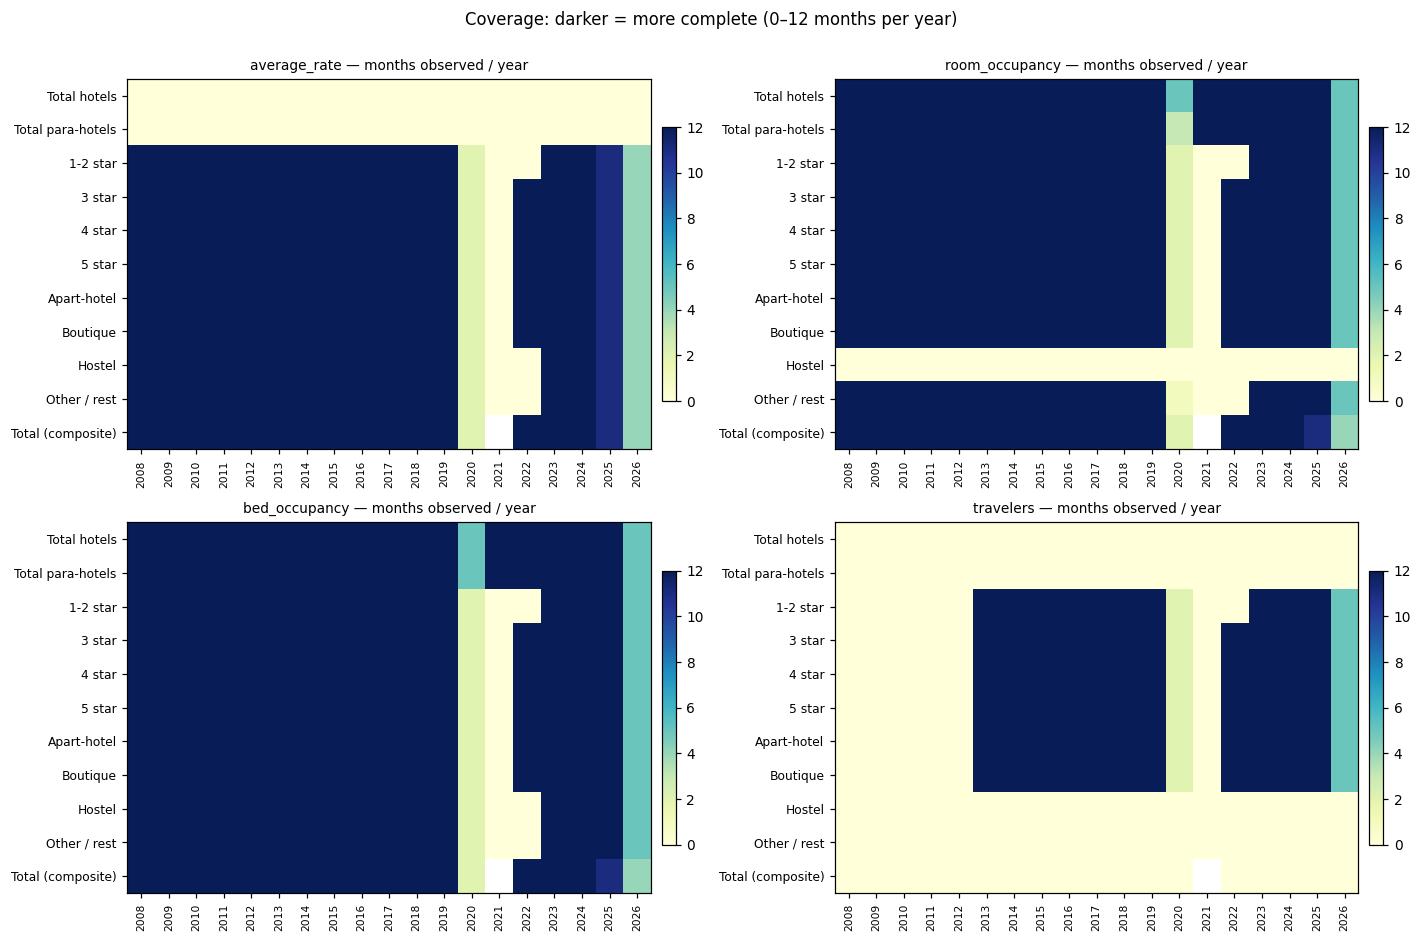

In [4]:
KEYVARS = ["average_rate", "room_occupancy", "bed_occupancy", "travelers"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
for ax, v in zip(axes.ravel(), KEYVARS):
    m = (df.assign(yr=df.date.dt.year)
           .pivot_table(index="hotel_category", columns="yr", values=v,
                        aggfunc=lambda s: s.notna().sum()))
    m = m.reindex(index=[c for c in CAT_ORDER if c in m.index])
    im = ax.imshow(m.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=12)
    ax.set_xticks(range(len(m.columns)))
    ax.set_xticklabels(m.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(m.index)))
    ax.set_yticklabels([LAB[c] for c in m.index], fontsize=8)
    ax.set_title(f"{v} — months observed / year", fontsize=9)
    ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
fig.suptitle("Coverage: darker = more complete (0–12 months per year)", y=1.0)
save(fig, "02_coverage_heatmap.png")

In [5]:
# why values are missing, straight from the cleaning step's missing_reason
miss = (panel_long[panel_long.missing_reason.fillna("").ne("")]
        .groupby(["variable", "missing_reason"]).size().rename("n_cells")
        .reset_index()
        .pivot(index="missing_reason", columns="variable", values="n_cells")
        .fillna(0).astype(int))
miss.loc["— TOTAL —"] = miss.sum()
miss

variable,average_rate,bed_occupancy,room_occupancy,travelers
missing_reason,,,,
covid_hole,176,190,170,132
covid_recovery_gap,36,36,36,12
hostel_room_occ_not_published,0,0,168,0
na_token,0,0,36,0
provisional_gap,16,0,6,0
— TOTAL —,228,226,416,144


## 3 · The analysis windows

Every month of the 4-star series, coloured by its role in the backtest. The main
analysis sample is `2018-01…2019-12 + 2022-01…2025-11`; **COVID 2020–2021 is
held out**; 2008–2017 is long-run nominal context only (no GBA deflator before
2016-04). The panel loads through 2026-05 but the analysis stops at 2025-11
(from 2025-12 the rates are provisional and straddle a data gap).

  [02_data_overview] figure                 02_sample_map.png                          


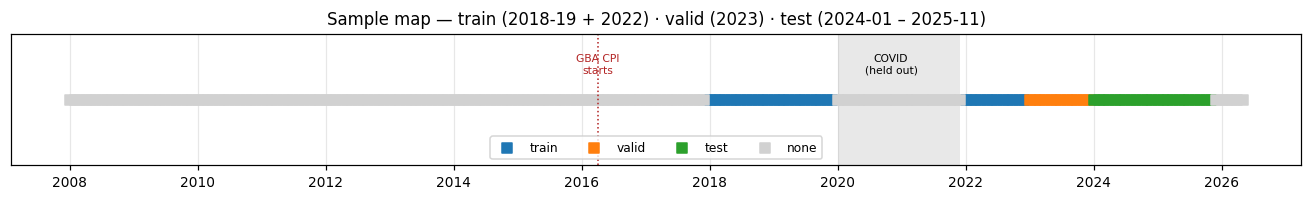

In [6]:
s4 = df[df.hotel_category == "stars_4"].sort_values("date")
colour = {"train": "tab:blue", "valid": "tab:orange", "test": "tab:green", "none": "0.82"}
fig, ax = plt.subplots(figsize=(12, 1.9))
for sp, col in colour.items():
    m = s4["split"] == sp
    ax.scatter(s4.loc[m, "date"], np.zeros(m.sum()), c=col, s=45, marker="s", label=sp)
covid_band(ax)
ax.axvline(pd.Timestamp(C.CPI_MIN_DATE), color="firebrick", ls=":", lw=1)
ax.annotate("GBA CPI\nstarts", (pd.Timestamp(C.CPI_MIN_DATE), 0.02),
            fontsize=7, color="firebrick", ha="center")
ax.annotate("COVID\n(held out)", (pd.Timestamp("2020-11-01"), 0.02), fontsize=7, ha="center")
ax.set_yticks([])
ax.set_ylim(-0.05, 0.05)
_te = s4.loc[s4.split == "test", "date"]
ax.set_title(f"Sample map — train (2018-19 + 2022) · valid (2023) · "
             f"test ({_te.min():%Y-%m} – {_te.max():%Y-%m})")
ax.legend(ncol=4, fontsize=8, loc="lower center")
save(fig, "02_sample_map.png")

## 4 · Nominal rates over the long run

Average room rate by category, 2008–2026, indexed to $100$ at 2018-01:
$100 \times P_t / P_{\text{2018-01}}$. Log scale — over the window the nominal
rate rises roughly $1000\times$.

  [02_data_overview] figure                 02_nominal_rates_longrun.png               


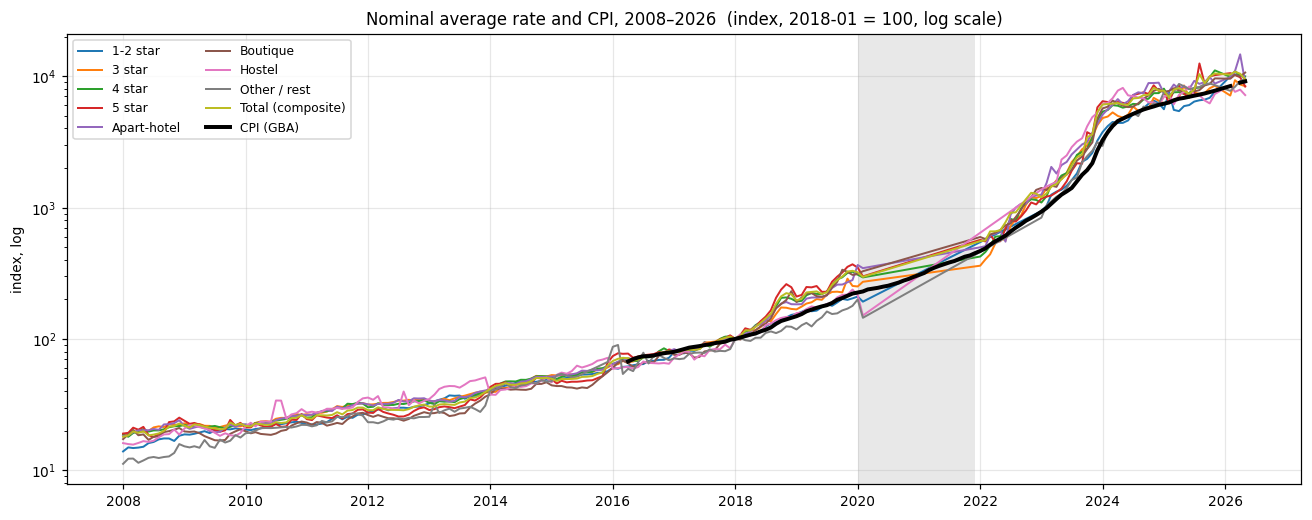

In [7]:
b0 = pd.Timestamp("2018-01-01")
piv = df.pivot_table(index="date", columns="hotel_category", values="average_rate")
fig, ax = plt.subplots(figsize=(12, 4.8))
for cat in [c for c in CAT_ORDER if c in piv.columns and piv[c].notna().any()]:
    s = piv[cat].dropna()
    if b0 not in s.index:
        continue
    ax.plot(s.index, s / s.loc[b0] * 100, lw=1.3, label=LAB[cat])
ax.plot(by_date.date, by_date.cpi_gba / by_date.set_index("date").cpi_gba.loc[b0] * 100,
        lw=2.6, color="k", label="CPI (GBA)")
covid_band(ax)
ax.set_yscale("log")
ax.set_title("Nominal average rate and CPI, 2008–2026  (index, 2018-01 = 100, log scale)")
ax.set_ylabel("index, log")
ax.legend(fontsize=8, ncol=2)
save(fig, "02_nominal_rates_longrun.png")

## 5 · The inflation environment

The project is about repricing *under inflation*, so this is the central
context. Monthly inflation is $\pi_t = \text{CPI}_t / \text{CPI}_{t-1} - 1$ and
the year-on-year rate is $\text{CPI}_t / \text{CPI}_{t-12} - 1$. The dashed
lines are the data-driven **regime terciles** of $\pi_t$ over the analysis
sample — the low / mid / high split the later notebooks use.

  [02_data_overview] figure                 02_inflation_environment.png               


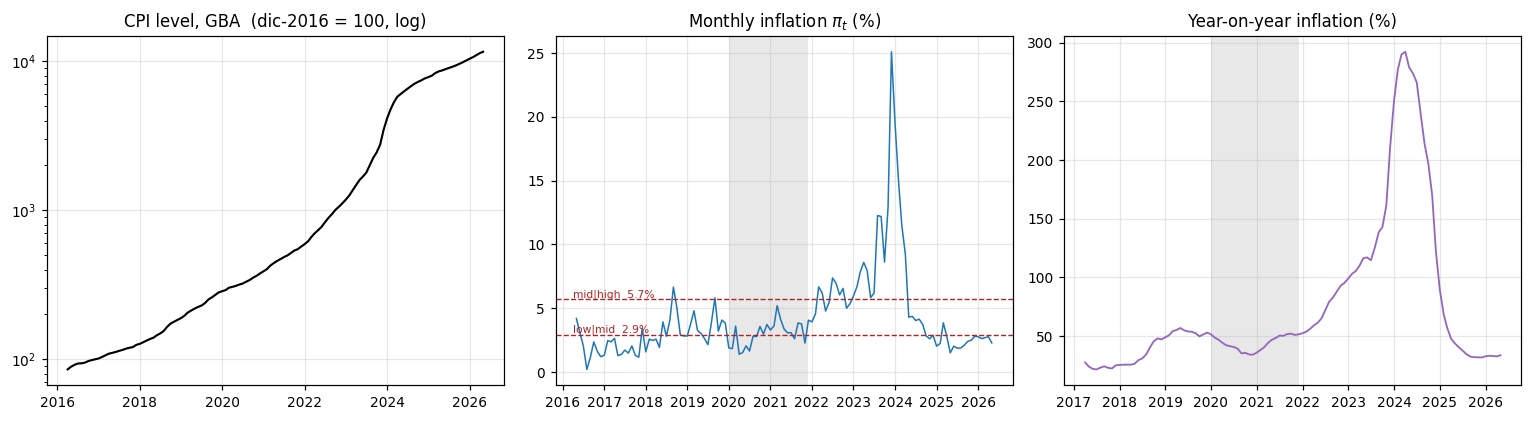

MoM inflation, GBA, analysis sample:
count    71.00
mean      5.36
std       4.13
min       1.50
25%       2.78
50%       4.06
75%       6.37
max      25.08


In [8]:
insamp = df[(df.in_sample == 1) & (df.hotel_category == "stars_4")]
edges = insamp["infl_mom_gba"].quantile(C.REGIME_QUANTILES).values
d = by_date.dropna(subset=["cpi_gba"])

fig, ax = plt.subplots(1, 3, figsize=(14, 3.9))
ax[0].plot(d.date, d.cpi_gba, lw=1.4, color="k")
ax[0].set_yscale("log")
ax[0].set_title(f"CPI level, GBA  ({C.CPI_BASE_LABEL}, log)")

ax[1].plot(d.date, d.infl_mom_gba, lw=1.0)
for e, lb in zip(edges[1:3], ["low|mid", "mid|high"]):
    ax[1].axhline(e, color="firebrick", ls="--", lw=0.9)
    ax[1].annotate(f"{lb}  {e:.1f}%", (d.date.min(), e), fontsize=7, color="firebrick",
                   va="bottom")
covid_band(ax[1])
ax[1].set_title("Monthly inflation $\\pi_t$ (%)")

ax[2].plot(d.date, d.infl_yoy_gba, lw=1.2, color="tab:purple")
covid_band(ax[2])
ax[2].set_title("Year-on-year inflation (%)")
for a in ax:
    a.set_xlabel("")
save(fig, "02_inflation_environment.png")

print("MoM inflation, GBA, analysis sample:")
print(insamp["infl_mom_gba"].describe().round(2).to_string())

## 5b · Annual inflation, and Argentina vs India

Two standard annual measures, both computed here from `cpi_gba` / `cpi_nac`:

* **Dec-over-Dec** — $\text{CPI}_{\text{Dec},\,y} \,/\, \text{CPI}_{\text{Dec},\,y-1} - 1$
* **Calendar-year average** — $\bar{\text{CPI}}_y \,/\, \bar{\text{CPI}}_{y-1} - 1$
  (the metric the World Bank reports, so it is the one used for the India
  comparison below).

India is the World Bank WDI series *Inflation, consumer prices (annual %)*
(`FP.CPI.TOTL.ZG`, calendar-year-average CPI), read from
`data/raw/India_CPI/`. 2016 is dropped from the table (the GBA index starts
2016-04, so there is no full prior year) and 2026 is still partial — both are
reported inline instead. The comparison is about **scale**: Argentine annual
inflation runs one to two orders of magnitude above India's, which is why every
price in this project is worked in *real* terms.

In [9]:
# India: World Bank WDI "Inflation, consumer prices (annual %)" (FP.CPI.TOTL.ZG),
# calendar-year-average CPI — the file in data/raw/India_CPI/.
_wb = pd.read_csv(next((C.DATA_RAW / "India_CPI").glob("API_FP.CPI.TOTL.ZG_*.csv")),
                  skiprows=4)
_ind = _wb.loc[_wb["Country Code"] == "IND"].iloc[0]
INDIA_CPI_AVG_PCT = {int(y): float(_ind[y]) for y in _ind.index
                     if y.isdigit() and pd.notna(_ind[y])}

_c = cpi.set_index("date").sort_index()
_yr = _c.index.year
rows = []
for y in range(2017, int(_yr.max()) + 1):
    r = {"year": y}
    for col, tag in [("cpi_gba", "GBA"), ("cpi_nac", "national")]:
        s = _c[col]
        cur, prev = s[_yr == y], s[_yr == y - 1]
        r[f"ARG_{tag}_yravg_%"] = ((cur.mean() / prev.mean() - 1) * 100
                                   if cur.notna().sum() == 12 and prev.notna().sum() == 12
                                   else np.nan)
        dcur = s[(_yr == y) & (_c.index.month == 12)]
        dprev = s[(_yr == y - 1) & (_c.index.month == 12)]
        r[f"ARG_{tag}_DecDec_%"] = ((dcur.iloc[0] / dprev.iloc[0] - 1) * 100
                                    if len(dcur) and len(dprev) and dprev.notna().all()
                                    else np.nan)
    r["INDIA_yravg_%"] = INDIA_CPI_AVG_PCT.get(y, np.nan)
    rows.append(r)

annual_infl = pd.DataFrame(rows).set_index("year")
annual_infl["ARG_over_INDIA_x"] = annual_infl["ARG_GBA_yravg_%"] / annual_infl["INDIA_yravg_%"]
annual_infl = (annual_infl[["ARG_GBA_DecDec_%", "ARG_GBA_yravg_%", "ARG_national_yravg_%",
                            "INDIA_yravg_%", "ARG_over_INDIA_x"]]
               .dropna(how="all").round(1))      # drop the partial 2026 row
annual_infl.to_csv(C.OUT_TAB / "annual_inflation.csv")
LOG.log("write", "annual_inflation.csv", len(annual_infl))

# years the GBA index cannot cover cleanly, reported inline instead of in the table
if (_yr == 2026).any():
    g26, g25 = _c["cpi_gba"][_yr == 2026], _c["cpi_gba"][_yr == 2025]
    last = _c["cpi_gba"].dropna()
    print(f"2026 YTD ({g26.index.min():%b}-{g26.index.max():%b}) year-avg vs 2025: "
          f"{(g26.mean() / g25.mean() - 1) * 100:+.1f}%   |   "
          f"12-month GBA inflation to {last.index[-1]:%b %Y}: "
          f"{(last.iloc[-1] / last.iloc[-13] - 1) * 100:+.1f}%")
annual_infl

  [02_data_overview] write                  annual_inflation.csv                    9  
2026 YTD (Jan-Jul) year-avg vs 2025: +26.0%   |   12-month GBA inflation to Jul 2026: +34.0%


,ARG_GBA_DecDec_%,ARG_GBA_yravg_%,ARG_national_yravg_%,INDIA_yravg_%,ARG_over_INDIA_x
year,,,,,
2017,25.0,NaN,NaN,3.3,NaN
2018,47.1,34.2,34.3,3.9,8.7
2019,52.9,52.8,53.5,3.7,14.2
2020,34.1,40.5,42.0,6.6,6.1
2021,51.4,47.1,48.4,5.1,9.2
2022,95.2,73.1,72.4,6.7,10.9
2023,210.1,134.0,133.5,5.6,23.7
2024,122.1,223.0,219.9,5.0,45.0
2025,31.7,42.8,41.9,2.4,17.9


  [02_data_overview] figure                 02_argentina_vs_india_inflation.png           


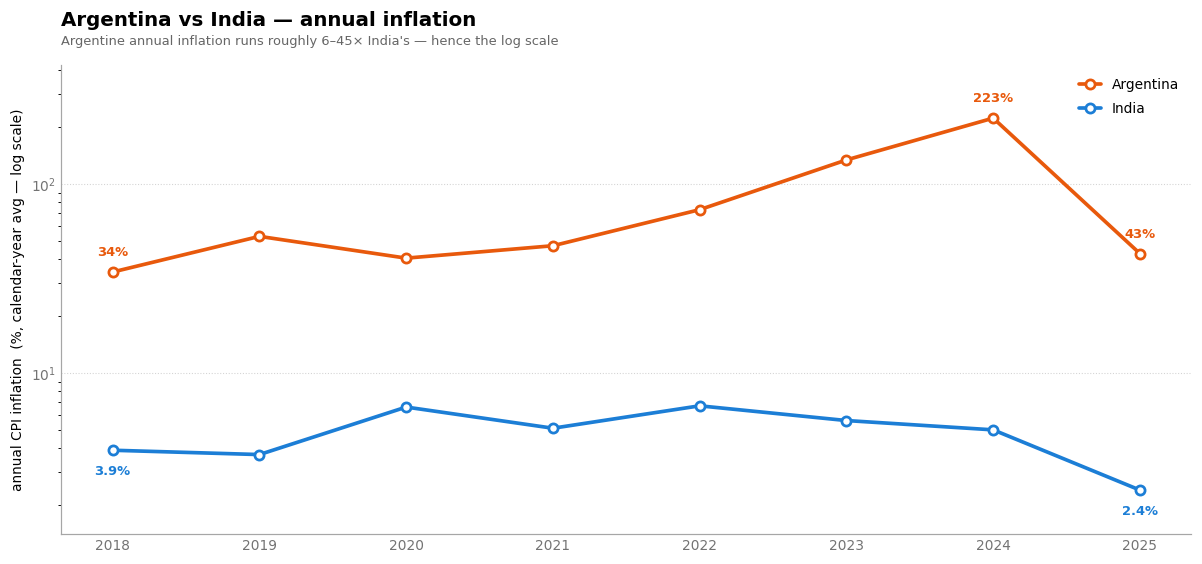

In [10]:
gyrs = [y for y in annual_infl.index
        if pd.notna(annual_infl.loc[y, "ARG_GBA_yravg_%"])
        and pd.notna(annual_infl.loc[y, "INDIA_yravg_%"])]
arg = annual_infl.loc[gyrs, "ARG_GBA_yravg_%"].to_numpy(float)
ind = annual_infl.loc[gyrs, "INDIA_yravg_%"].to_numpy(float)
yrs = np.asarray(gyrs, dtype=int)

C_ARG, C_IND = "#e8590c", "#1c7ed6"          # warm = Argentina, cool = India (CVD-safe pair)

fig, ax = plt.subplots(figsize=(11, 5.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for series, col, lab in [(arg, C_ARG, "Argentina"),
                         (ind, C_IND, "India")]:
    ax.plot(yrs, series, color=col, lw=2.4, marker="o", ms=6, mfc="white",
            mec=col, mew=1.8, solid_capstyle="round", solid_joinstyle="round",
            clip_on=False, zorder=3, label=lab)

# selective direct labels: each series' endpoints, plus Argentina's peak
def tag(xi, v, col, dy, fmt="{:.0f}%"):
    ax.annotate(fmt.format(v), (xi, v), textcoords="offset points", xytext=(0, dy),
                ha="center", va="center", fontsize=8.5, fontweight="bold", color=col)

pk = int(yrs[arg.argmax()])
for xi, v in zip(yrs, arg):
    if xi in (yrs[0], yrs[-1], pk):
        tag(xi, v, C_ARG, 13)
for xi, v in zip(yrs, ind):
    if xi in (yrs[0], yrs[-1]):
        tag(xi, v, C_IND, -14, "{:.1f}%")

ax.set_yscale("log")
ax.set_ylim(ind.min() / 1.7, arg.max() * 1.9)
ax.set_xticks(yrs)
ax.margins(x=0.05)
ax.set_ylabel("annual CPI inflation  (%, calendar-year avg — log scale)")
ax.set_title("Argentina vs India — annual inflation", fontsize=13, fontweight="bold",
             loc="left", pad=26)
ax.text(0, 1.045, "Argentine annual inflation runs roughly 6–45× India's — hence the log "
        "scale",
        transform=ax.transAxes, fontsize=8.5, color="0.4")

ax.grid(axis="y", ls=":", lw=0.7, alpha=.55)
ax.grid(axis="x", visible=False)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
for sp in ("left", "bottom"):
    ax.spines[sp].set_color("0.65")
ax.tick_params(colors="0.45", length=0)
ax.legend(frameon=False, fontsize=9, loc="upper right", handlelength=1.6,
          labelspacing=0.7)

save(fig, "02_argentina_vs_india_inflation.png")

## 5c · Cumulative price level since 2017

Compounding annual inflation into a **price-level factor**: one unit of currency
in the base year buys, in a later year $y$, only what
$\text{CPI}_y / \text{CPI}_{\text{base}}$ units buy then. So the table reads
*"1 rupee / 1 peso in `BASE` → this many rupees / pesos in year $y$"* — i.e. what
a single base-year unit now costs to replace.

Argentina uses the `cpi_gba` calendar-year-average level directly; India
compounds the World Bank annual rates, $\prod_t (1 + \pi_t)$. Base year is
`BASE` (default 2017, the first full year of the GBA index); change it and
re-run to re-anchor.

  [02_data_overview] write                  currency_erosion.csv                    9  
Base 2017 -> 2025  (8 years):
  India     :  1 rupee in 2017  buys what  1.46 rupees  buy in 2025
  Argentina :  1 peso  in 2017  buys what  79.19 pesos   buy in 2025
  -> the peso debased ~54x faster than the rupee.


  [02_data_overview] figure                 02_currency_erosion.png                    


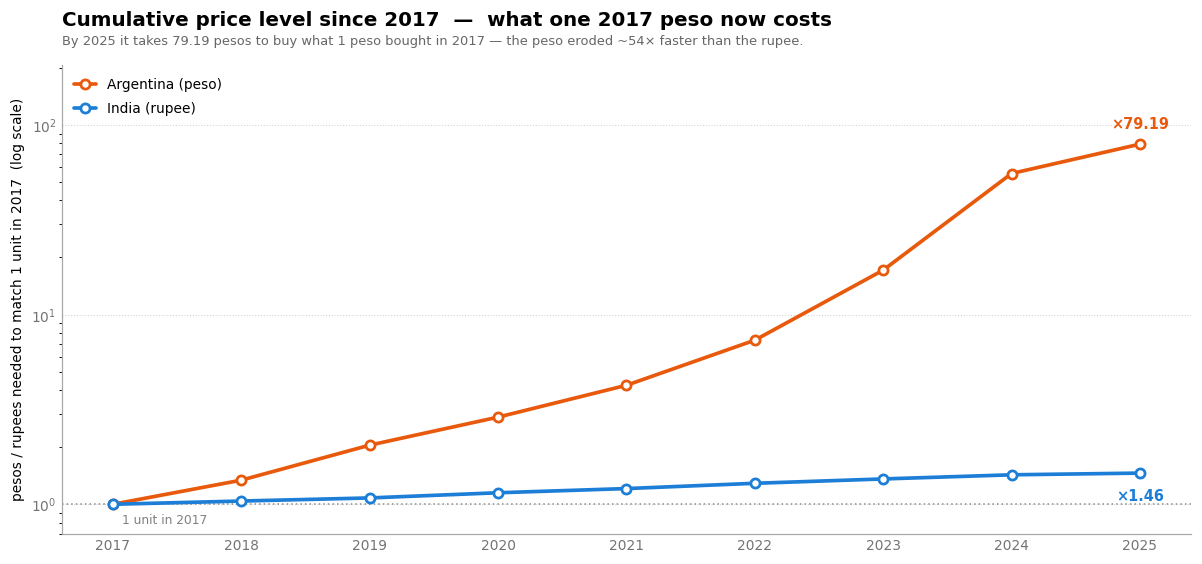

,india_1rupee_becomes,argentina_1peso_becomes
year,,
2017,1.00,1.00
2018,1.04,1.34
2019,1.08,2.05
2020,1.15,2.88
2021,1.21,4.24
2022,1.29,7.33
2023,1.36,17.16
2024,1.43,55.44
2025,1.46,79.19


In [11]:
BASE = 2017      # first full calendar year of the GBA CPI index

# India — compound the World Bank annual % into a price-level index (BASE = 1.0)
_ir = (pd.Series(INDIA_CPI_AVG_PCT).sort_index() / 100)
india_factor = pd.Series({y: float((1 + _ir.loc[BASE + 1:y]).prod())
                          for y in _ir.index if y >= BASE})

# Argentina — ratio of calendar-year-average cpi_gba levels (full years only)
_gavg = _c["cpi_gba"].groupby(_yr).mean()
_gfull = _c["cpi_gba"].groupby(_yr).count().eq(12)
arg_factor = (_gavg / _gavg.loc[BASE])[_gfull].loc[BASE:]

ppp = pd.DataFrame({"india_1rupee_becomes": india_factor,
                    "argentina_1peso_becomes": arg_factor}).dropna(how="all").round(2)
ppp.index.name = "year"
ppp.to_csv(C.OUT_TAB / "currency_erosion.csv")
LOG.log("write", "currency_erosion.csv", len(ppp))

_last = int(ppp.dropna().index.max())
ri, pa = ppp.loc[_last, "india_1rupee_becomes"], ppp.loc[_last, "argentina_1peso_becomes"]
print(f"Base {BASE} -> {_last}  ({_last - BASE} years):")
print(f"  India     :  1 rupee in {BASE}  buys what  {ri:.2f} rupees  buy in {_last}")
print(f"  Argentina :  1 peso  in {BASE}  buys what  {pa:,.2f} pesos   buy in {_last}")
print(f"  -> the peso debased ~{pa / ri:.0f}x faster than the rupee.")

C_ARG, C_IND = "#e8590c", "#1c7ed6"          # warm = Argentina, cool = India (CVD-safe pair)
s_arg = ppp["argentina_1peso_becomes"].dropna()
s_ind = ppp["india_1rupee_becomes"].dropna()

fig, ax = plt.subplots(figsize=(11, 5.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for s, col, lab in [(s_arg, C_ARG, "Argentina (peso)"),
                    (s_ind, C_IND, "India (rupee)")]:
    ax.plot(s.index, s.values, color=col, lw=2.4, marker="o", ms=6, mfc="white",
            mec=col, mew=1.8, solid_capstyle="round", solid_joinstyle="round",
            clip_on=False, zorder=3, label=lab)

ax.axhline(1, color="0.55", lw=1, ls=(0, (1, 2)), zorder=1)
ax.annotate(f"1 unit in {BASE}", (s_arg.index.min(), 1), textcoords="offset points",
            xytext=(6, -13), fontsize=8, color="0.5")

# selective direct labels: where each series ends up
ax.annotate(f"×{pa:,.2f}", (s_arg.index[-1], s_arg.iloc[-1]), textcoords="offset points",
            xytext=(0, 13), ha="center", va="center", fontsize=9.5, fontweight="bold",
            color=C_ARG)
ax.annotate(f"×{ri:.2f}", (s_ind.index[-1], s_ind.iloc[-1]), textcoords="offset points",
            xytext=(0, -15), ha="center", va="center", fontsize=9.5, fontweight="bold",
            color=C_IND)

ax.set_yscale("log")
ax.set_ylim(0.7, s_arg.max() * 2.6)
ax.set_xticks(list(s_arg.index))
ax.margins(x=0.05)
ax.set_ylabel(f"pesos / rupees needed to match 1 unit in {BASE}  (log scale)")
ax.set_title(f"Cumulative price level since {BASE}  —  what one {BASE} peso now costs",
             fontsize=13, fontweight="bold", loc="left", pad=26)
ax.text(0, 1.045, f"By {_last} it takes {pa:,.2f} pesos to buy what 1 peso bought in "
        f"{BASE} — the peso eroded ~{pa / ri:.0f}× faster than the rupee.",
        transform=ax.transAxes, fontsize=8.5, color="0.4")

ax.grid(axis="y", ls=":", lw=0.7, alpha=.55)
ax.grid(axis="x", visible=False)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
for sp in ("left", "bottom"):
    ax.spines[sp].set_color("0.65")
ax.tick_params(colors="0.45", length=0)
ax.legend(frameon=False, fontsize=9, loc="upper left", handlelength=1.6,
          labelspacing=0.7)

save(fig, "02_currency_erosion.png")
ppp

## 6 · Real rates — did prices keep pace?

Real rate $= \text{average\_rate}_t / \text{CPI}_t \times 100$ (constant
dic-2016 pesos), shown indexed to its first observation. A flat line means the
nominal rate exactly tracked inflation; dips are real under-shooting. Only drawn
where the GBA deflator exists (from 2016-04).

  [02_data_overview] figure                 02_real_rates.png                          


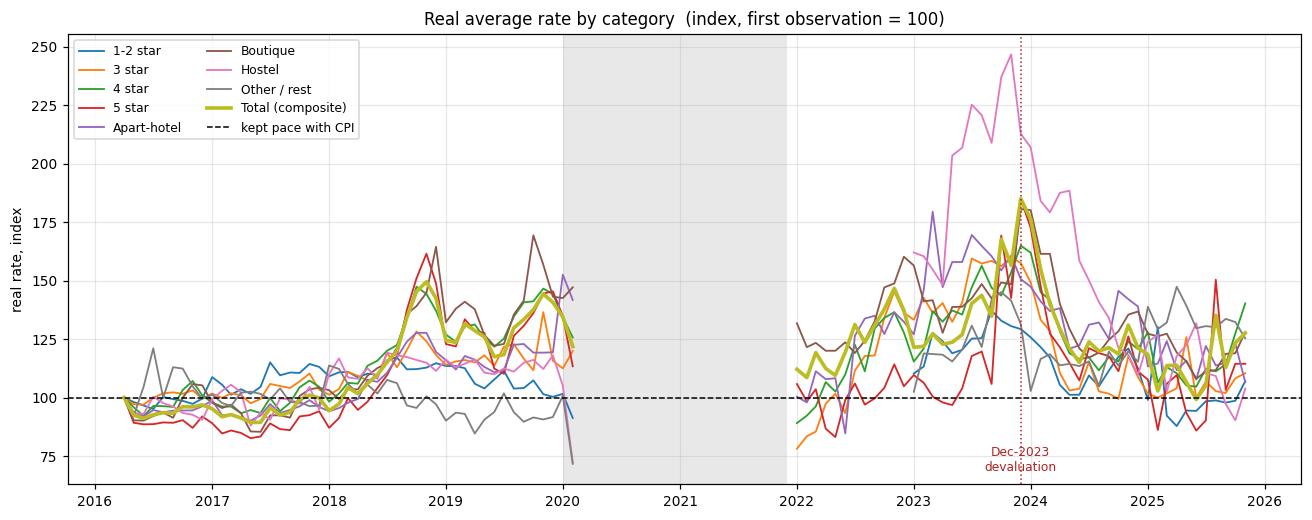

In [12]:
full = pd.date_range(C.CPI_MIN_DATE, C.DATA_END, freq="MS")
fig, ax = plt.subplots(figsize=(12, 4.8))
for cat in [c for c in CAT_ORDER if c in df.hotel_category.unique()]:
    s = df[df.hotel_category == cat].set_index("date")["real_rate_gba"].reindex(full)
    base = s.dropna()
    if base.empty:
        continue
    lw = 2.4 if cat == C.COMPOSITE_TOTAL else 1.2
    ax.plot(full, s / base.iloc[0] * 100, lw=lw, label=LAB[cat])
ax.axhline(100, color="k", ls="--", lw=1, label="kept pace with CPI")
covid_band(ax)
ax.axvline(pd.Timestamp("2023-12-01"), color="firebrick", ls=":", lw=1)
ax.annotate("Dec-2023\ndevaluation", (pd.Timestamp("2023-12-01"), ax.get_ylim()[0] + 6),
            color="firebrick", fontsize=8, ha="center")
ax.set_title("Real average rate by category  (index, first observation = 100)")
ax.set_ylabel("real rate, index")
ax.legend(fontsize=8, ncol=2)
save(fig, "02_real_rates.png")

## 7 · Occupancy — level and seasonality

Room occupancy is a share in $[0, 100]$. Left: the series by category. Right:
the calendar-month pattern pooled over the four star tiers — the Argentine
summer (Jan–Feb) and the winter break (Jul) stand out.

  [02_data_overview] figure                 02_occupancy.png                           


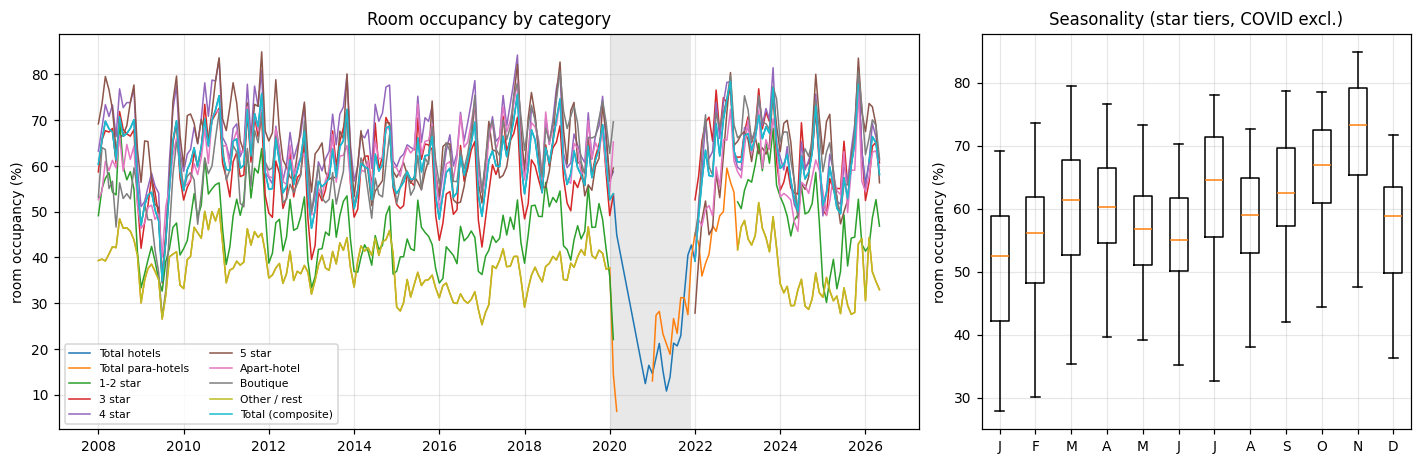

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={"width_ratios": [2, 1]})
occ = df.pivot_table(index="date", columns="hotel_category", values="room_occupancy")
for cat in [c for c in CAT_ORDER if c in occ.columns and occ[c].notna().any()]:
    ax[0].plot(occ.index, occ[cat], lw=1.0, label=LAB[cat])
covid_band(ax[0])
ax[0].set_ylabel("room occupancy (%)")
ax[0].set_title("Room occupancy by category")
ax[0].legend(fontsize=7, ncol=2)

core = df[df.hotel_category.isin(C.CORE_CATEGORIES) & (df.is_covid == 0)]
box = [core.loc[core.date.dt.month == m, "room_occupancy"].dropna() for m in range(1, 13)]
ax[1].boxplot(box, tick_labels=list("JFMAMJJASOND"), showfliers=False)
ax[1].set_ylabel("room occupancy (%)")
ax[1].set_title("Seasonality (star tiers, COVID excl.)")
save(fig, "02_occupancy.png")

## 8 · Monthly price changes

The log change $\Delta \ln P_t = \ln P_t - \ln P_{t-1}$, per category, over the
analysis sample. `average_rate` is a category **mean**, not a posted price, so
it moves almost every month — the mass is away from zero and skewed positive.

  [02_data_overview] figure                 02_price_change_dist.png                   


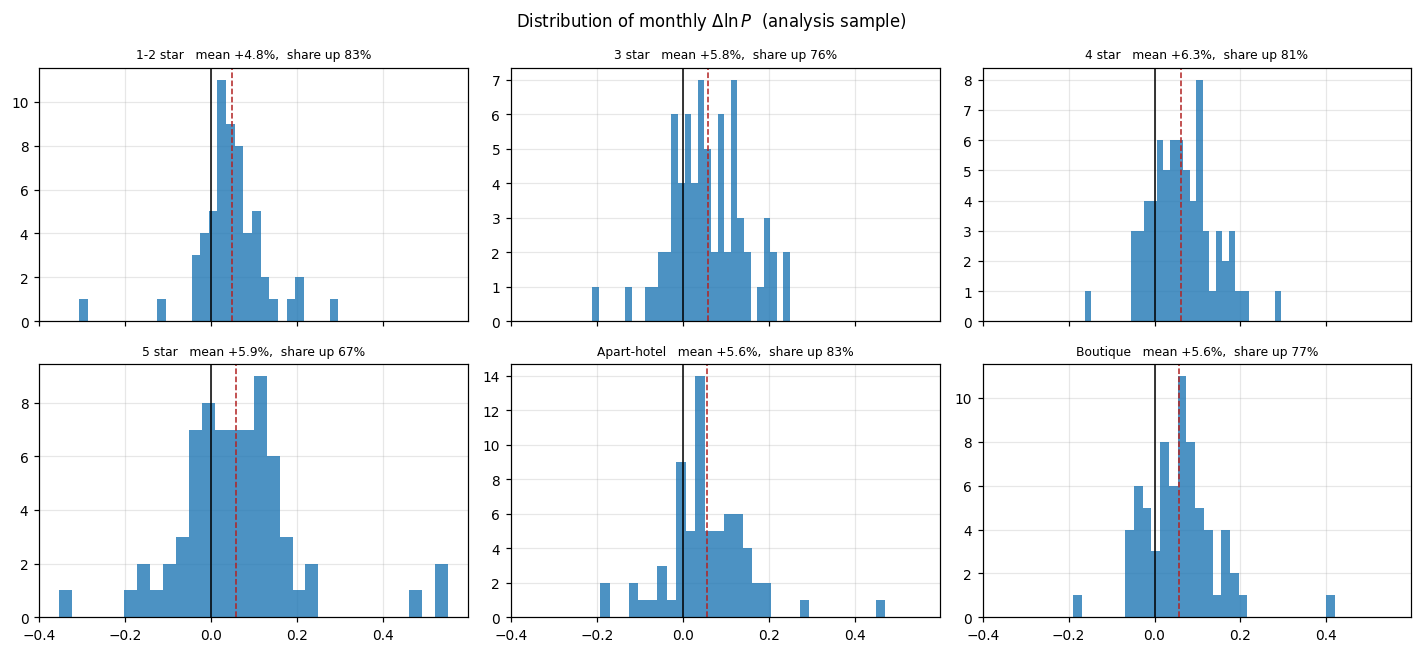

In [14]:
chg = df[(df.in_sample == 1) & df.hotel_category.isin(C.MODEL_CATEGORIES)]
cats = [c for c in C.MODEL_CATEGORIES if c in chg.hotel_category.unique()]
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
for ax, cat in zip(axes.ravel(), cats):
    v = chg.loc[chg.hotel_category == cat, "dln_average_rate"].dropna()
    ax.hist(v, bins=30, color="tab:blue", alpha=.8)
    ax.axvline(0, color="k", lw=1)
    ax.axvline(v.mean(), color="firebrick", ls="--", lw=1)
    ax.set_title(f"{LAB[cat]}   mean {v.mean():+.1%},  share up {(v > 0).mean():.0%}",
                 fontsize=8)
for ax in axes.ravel()[len(cats):]:
    ax.set_visible(False)
fig.suptitle(r"Distribution of monthly $\Delta\ln P$  (analysis sample)")
save(fig, "02_price_change_dist.png")

## 9 · Rate changes vs inflation

A first look at pass-through (formalised in notebook 03): monthly
$\Delta \ln P_t$ against monthly inflation $\pi_t$, pooled over the star tiers
and coloured by inflation regime. The dashed line is one-for-one pass-through.

  [02_data_overview] figure                 02_passthrough_scatter.png                 


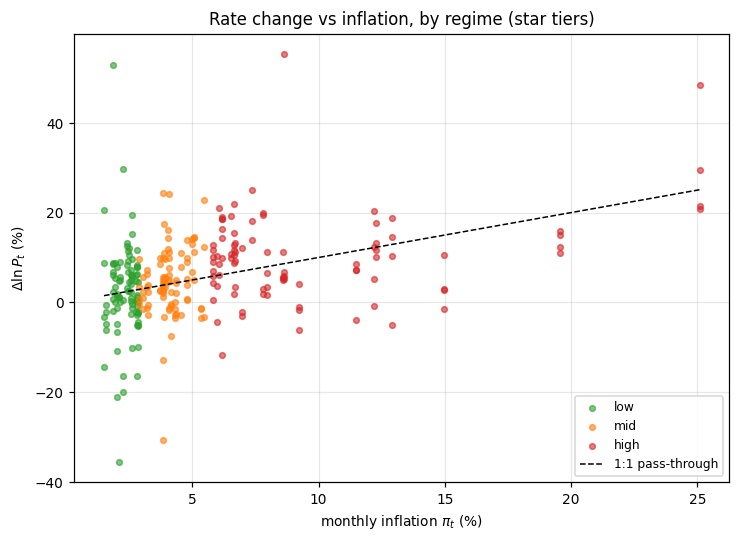

In [15]:
p = df[(df.in_sample == 1) & df.hotel_category.isin(C.CORE_CATEGORIES)].copy()
p["pi"] = p["infl_mom_gba_frac"]
p = p.dropna(subset=["dln_average_rate", "pi"])
edges = p["infl_mom_gba"].quantile(C.REGIME_QUANTILES).values
p["regime"] = pd.cut(p["infl_mom_gba"], edges, include_lowest=True, labels=C.REGIME_LABELS)
fig, ax = plt.subplots(figsize=(6.8, 5))
for r, col in zip(C.REGIME_LABELS, ["tab:green", "tab:orange", "tab:red"]):
    g = p[p.regime == r]
    ax.scatter(g["pi"] * 100, g["dln_average_rate"] * 100, s=14, alpha=.6, color=col, label=r)
lim = [p["pi"].min() * 100, p["pi"].max() * 100]
ax.plot(lim, lim, "k--", lw=1, label="1:1 pass-through")
ax.set_xlabel(r"monthly inflation $\pi_t$ (%)")
ax.set_ylabel(r"$\Delta\ln P_t$ (%)")
ax.set_title("Rate change vs inflation, by regime (star tiers)")
ax.legend(fontsize=8)
save(fig, "02_passthrough_scatter.png")

## 10 · Capacity

Capacity is a **quarterly** snapshot (attached to the monthly panel as-of the
nearest prior quarter). Establishments and available room-nights by category,
`ehoba` taxonomy only.

  [02_data_overview] figure                 02_capacity.png                            


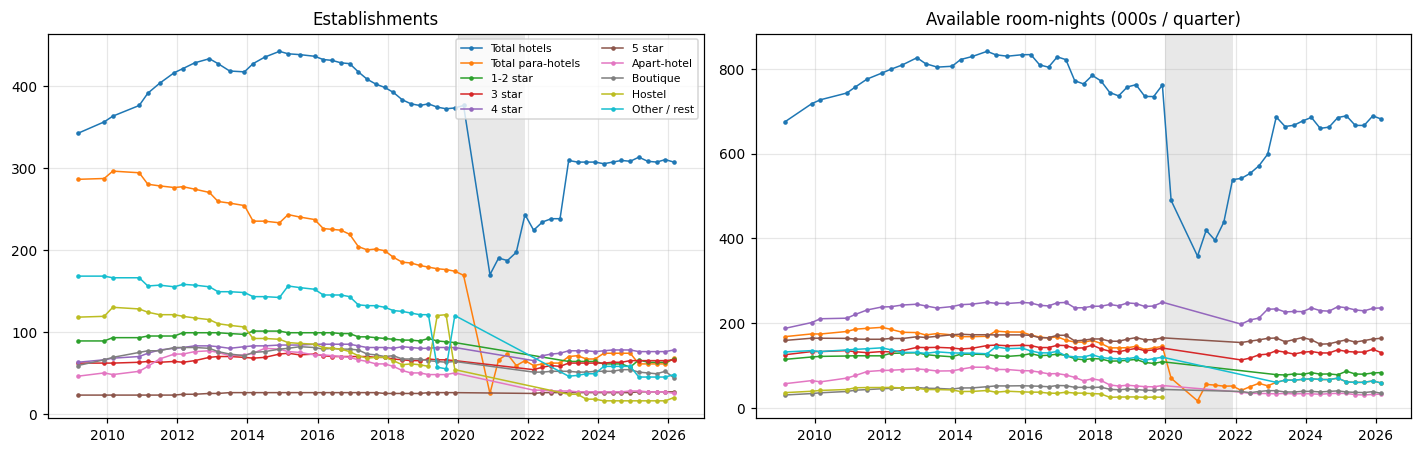

In [16]:
cap = capq[capq.source_taxonomy == "ehoba"].copy()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for cat in [c for c in CAT_ORDER if c in cap.hotel_category.unique()]:
    g = cap[cap.hotel_category == cat].sort_values("date")
    ax[0].plot(g.date, g.establishments, marker="o", ms=2, lw=1, label=LAB[cat])
    ax[1].plot(g.date, g.available_room_nights / 1e3, marker="o", ms=2, lw=1, label=LAB[cat])
covid_band(ax[0])
covid_band(ax[1])
ax[0].set_title("Establishments")
ax[1].set_title("Available room-nights (000s / quarter)")
ax[0].legend(fontsize=7, ncol=2)
save(fig, "02_capacity.png")

## 11 · Category comparison at a glance

One row per category over the main analysis sample (COVID held out): how much
data, price and real-price level and variability, occupancy, inflation exposure,
and the size / direction of the typical monthly price move.

In [17]:
S = df[(df.in_sample == 1) & df.hotel_category.isin(C.MODEL_CATEGORIES + [C.COMPOSITE_TOTAL])]
rows = []
for cat, s in S.groupby("hotel_category"):
    s = s.sort_values("date")
    real = s["real_rate_gba"].dropna()
    d = s["dln_average_rate"].dropna()
    rows.append(dict(
        category=LAB[cat],
        months=len(s),
        rate_obs=int(s["average_rate"].notna().sum()),
        first_rate=s.loc[s["average_rate"].notna(), "date"].min(),
        nominal_rate_mean=round(s["average_rate"].mean(), 0),
        real_rate_mean=round(real.mean(), 0) if len(real) else np.nan,
        real_rate_cv_pct=round(real.std() / real.mean() * 100, 1) if len(real) else np.nan,
        room_occ_mean=round(s["room_occupancy"].mean(), 1),
        infl_mom_mean_pct=round(s["infl_mom_gba"].mean(), 2),
        mean_abs_dlnP_pct=round(d.abs().mean() * 100, 1),
        share_months_up=round((d > 0).mean(), 2),
    ))
summary = pd.DataFrame(rows).set_index("category")
LOG.log("summary", "category comparison", len(summary))
summary

  [02_data_overview] summary                category comparison                     7  


,months,rate_obs,first_rate,nominal_rate_mean,real_rate_mean,real_rate_cv_pct,room_occ_mean,infl_mom_mean_pct,mean_abs_dlnP_pct,share_months_up
category,,,,,,,,,,
Apart-hotel,71,71,2018-01-01,34924.0,1163.0,15.5,59.9,5.36,8.3,0.83
Boutique,71,71,2018-01-01,58298.0,2020.0,13.4,66.2,5.36,7.6,0.77
1-2 star,71,59,2018-01-01,18410.0,561.0,9.7,49.1,5.36,6.9,0.83
3 star,71,71,2018-01-01,22536.0,791.0,16.0,62.2,5.36,8.0,0.76
4 star,71,71,2018-01-01,35870.0,1236.0,13.4,64.4,5.36,7.6,0.81
5 star,71,71,2018-01-01,93863.0,3215.0,18.7,62.4,5.36,10.7,0.67
Total (composite),71,71,2018-01-01,45849.0,1578.0,13.7,61.6,5.36,8.8,0.79


## 12 · How the modelling variables move together

Pearson correlations over the analysis-sample rows for a curated set of numeric
columns. Read it as orientation, not inference — several of these are mechanical
(`real_rate` is `average_rate` divided by `cpi`).

  [02_data_overview] figure                 02_correlations.png                        


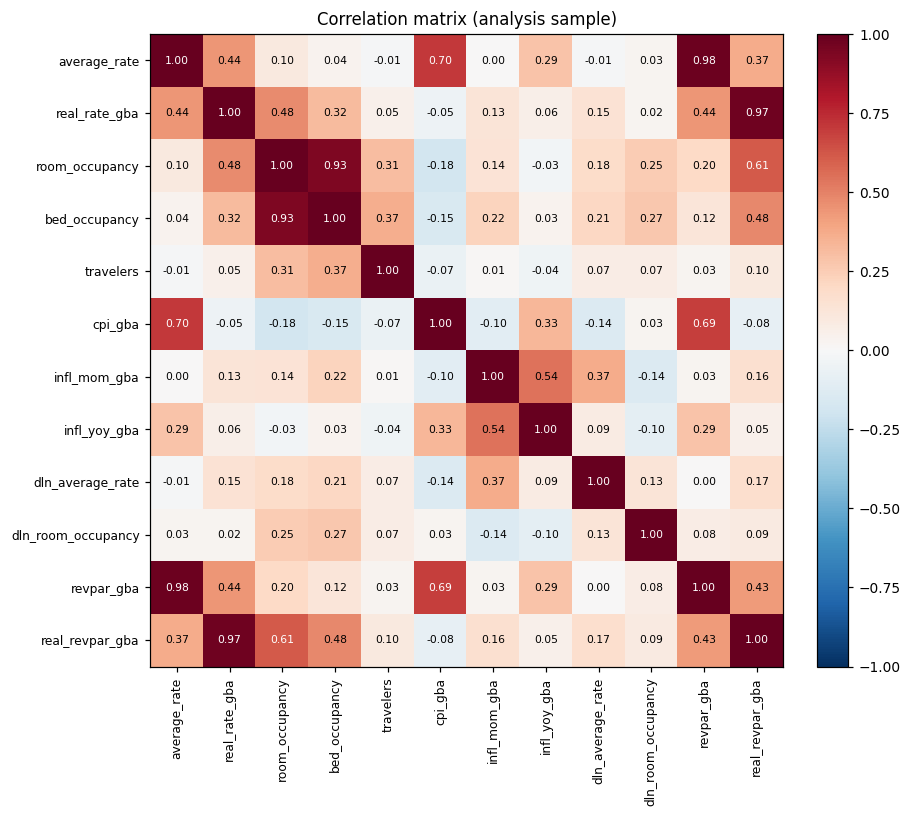

In [18]:
cols = ["average_rate", "real_rate_gba", "room_occupancy", "bed_occupancy",
        "travelers", "cpi_gba", "infl_mom_gba", "infl_yoy_gba",
        "dln_average_rate", "dln_room_occupancy", "revpar_gba", "real_revpar_gba"]
cols = [c for c in cols if c in df.columns]
corr = df.loc[df.in_sample == 1, cols].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=8)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center",
                fontsize=7, color="white" if abs(corr.values[i, j]) > 0.55 else "black")
ax.grid(False)
ax.set_title("Correlation matrix (analysis sample)")
fig.colorbar(im, fraction=0.046, pad=0.04)
save(fig, "02_correlations.png")

In [19]:
LOG.flush()
print("02_data_overview complete.")

02_data_overview complete.
